In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from scipy import stats
import warnings

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", "{:.4f}".format)

RANDOM_STATE = 42
sns.set_theme(style="whitegrid", palette="muted", font_scale=1.1)

In [3]:
train = pd.read_csv("dataset/UNSW_NB15_train_40k.csv")
print(f"Shape : {train.shape}")
print(f"Rows  : {train.shape[0]:,}  |  Columns : {train.shape[1]}")

Shape : (175341, 36)
Rows  : 175,341  |  Columns : 36


In [4]:
train

,dur,proto,service,state,spkts,dpkts,sbytes,dbytes,rate,sload,dload,sloss,dloss,sinpkt,dinpkt,sjit,djit,swin,stcpb,dtcpb,dwin,tcprtt,synack,ackdat,smean,dmean,trans_depth,response_body_len,ct_src_dport_ltm,ct_dst_sport_ltm,is_ftp_login,ct_ftp_cmd,ct_flw_http_mthd,is_sm_ips_ports,attack_cat,label
0,0.1215,tcp,-,FIN,6,4,258,172,74.0875,14158.9420,8495.3650,0,0,24.2956,8.3750,30.1775,11.8306,255,621772692,2202533631,255,0.0000,0.0000,0.0000,43,43,0,0,1,1,0,0,0,0,Normal,0
1,0.6499,tcp,-,FIN,14,38,734,42014,78.4734,8395.1120,503571.3000,2,17,49.9150,15.4329,61.4269,1387.7783,255,1417884146,3077387971,255,0.0000,0.0000,0.0000,52,1106,0,0,1,1,0,0,0,0,Normal,0
2,1.6231,tcp,-,FIN,8,16,364,13186,14.1702,1572.2719,60929.2300,1,6,231.8756,102.7372,17179.5860,11420.9260,255,2116150707,2963114973,255,0.1119,0.0615,0.0504,46,824,0,0,1,1,0,0,0,0,Normal,0
3,1.6816,tcp,ftp,FIN,12,12,628,770,13.6771,2740.1790,3358.6220,1,3,152.8765,90.2357,259.0802,4991.7847,255,1107119177,1047442890,255,0.0000,0.0000,0.0000,52,64,0,0,1,1,1,1,0,0,Normal,0
4,0.4495,tcp,-,FIN,10,6,534,268,33.3738,8561.4990,3987.0598,2,1,47.7503,75.6596,2415.8376,115.8070,255,2436137549,1977154190,255,0.1284,0.0711,0.0572,53,45,0,0,2,1,0,0,0,0,Normal,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
175336,0.0000,udp,dns,INT,2,0,114,0,111111.1100,50666664.0000,0.0000,0,0,0.0090,0.0000,0.0000,0.0000,0,0,0,0,0.0000,0.0000,0.0000,57,0,0,0,24,13,0,0,0,0,Generic,1
175337,0.5058,tcp,-,FIN,10,8,620,354,33.6126,8826.2860,4903.4920,2,1,54.4001,66.9806,3721.0688,120.1777,255,3518776216,3453092386,255,0.0994,0.0369,0.0625,62,44,0,0,1,1,0,0,0,0,Shellcode,1
175338,0.0000,udp,dns,INT,2,0,114,0,111111.1100,50666664.0000,0.0000,0,0,0.0090,0.0000,0.0000,0.0000,0,0,0,0,0.0000,0.0000,0.0000,57,0,0,0,3,3,0,0,0,0,Generic,1
175339,0.0000,udp,dns,INT,2,0,114,0,111111.1100,50666664.0000,0.0000,0,0,0.0090,0.0000,0.0000,0.0000,0,0,0,0,0.0000,0.0000,0.0000,57,0,0,0,30,14,0,0,0,0,Generic,1


In [5]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 175341 entries, 0 to 175340
Data columns (total 36 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   dur                175341 non-null  float64
 1   proto              175341 non-null  object 
 2   service            175341 non-null  object 
 3   state              175341 non-null  object 
 4   spkts              175341 non-null  int64  
 5   dpkts              175341 non-null  int64  
 6   sbytes             175341 non-null  int64  
 7   dbytes             175341 non-null  int64  
 8   rate               175341 non-null  float64
 9   sload              175341 non-null  float64
 10  dload              175341 non-null  float64
 11  sloss              175341 non-null  int64  
 12  dloss              175341 non-null  int64  
 13  sinpkt             175341 non-null  float64
 14  dinpkt             175341 non-null  float64
 15  sjit               175341 non-null  float64
 16  dj

In [6]:

train.describe(include=[np.number]).T.style.background_gradient(cmap="Blues", subset=["mean", "std", "max"])

,count,mean,std,min,25%,50%,75%,max
dur,175341.000000,1.359389,6.480249,0.000000,0.000008,0.001582,0.668069,59.999990
spkts,175341.000000,20.298664,136.887597,1.000000,2.000000,2.000000,12.000000,9616.000000
dpkts,175341.000000,18.969591,110.258271,0.000000,0.000000,2.000000,10.000000,10974.000000
sbytes,175341.000000,8844.843836,174765.644309,28.000000,114.000000,430.000000,1418.000000,12965233.000000
dbytes,175341.000000,14928.918564,143654.217718,0.000000,0.000000,164.000000,1102.000000,14655550.000000
rate,175341.000000,95406.185630,165400.975918,0.000000,32.786140,3225.806600,125000.000000,1000000.000000
sload,175341.000000,73454033.333701,188357446.780700,0.000000,13053.339000,879674.750000,88888890.000000,5988000300.000000
dload,175341.000000,671205.574186,2421312.388778,0.000000,0.000000,1447.022700,27844.871000,22422730.000000
sloss,175341.000000,4.953000,66.005059,0.000000,0.000000,0.000000,3.000000,4803.000000
dloss,175341.000000,6.948010,52.732999,0.000000,0.000000,0.000000,2.000000,5484.000000


In [7]:
cat_cols = train.select_dtypes(include="object").columns.tolist()
print("Categorical columns:", cat_cols)
train[cat_cols].describe()

Categorical columns: ['proto', 'service', 'state', 'attack_cat']


,proto,service,state,attack_cat
count,175341,175341,175341,175341
unique,133,13,9,10
top,tcp,-,INT,Normal
freq,79946,94168,82275,56000


In [8]:
missing = train.isnull().sum()
missing_pct = (missing / len(train) * 100).round(2)
missing_df = pd.DataFrame({"Missing Count": missing, "Missing %": missing_pct})
missing_df = missing_df[missing_df["Missing Count"] > 0]

if missing_df.empty:
    print("No missing values found in the training dataset.")
else:
    print(missing_df)

No missing values found in the training dataset.


In [9]:
n_dupes = train.duplicated().sum()
print(f"Duplicate rows : {n_dupes} ({n_dupes / len(train) * 100:.2f}%)")

Duplicate rows : 78519 (44.78%)


In [10]:
label_counts = train["label"].value_counts()
label_pct    = train["label"].value_counts(normalize=True) * 100

dist_df = pd.DataFrame({
    "Label":      label_counts.index.map({0: "Normal", 1: "Attack"}),
    "Count":      label_counts.values,
    "Percentage": label_pct.values.round(2)
})
print(dist_df.to_string(index=False))

 Label  Count  Percentage
Attack 119341     68.0600
Normal  56000     31.9400


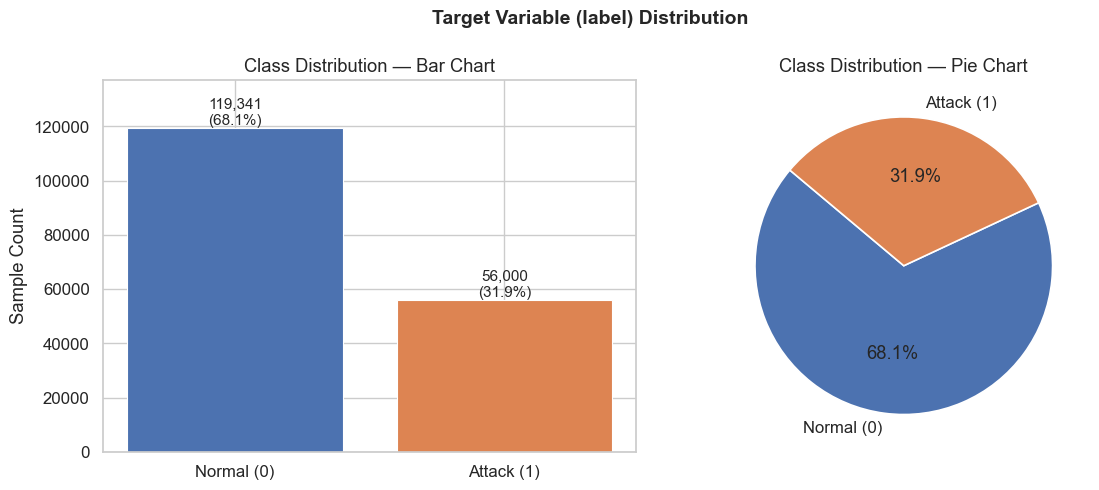

In [11]:

fig, axes = plt.subplots(1, 2, figsize=(12, 5))


axes[0].bar(["Normal (0)", "Attack (1)"], label_counts.values,
            color=["#4C72B0", "#DD8452"], edgecolor="white", linewidth=0.8)
for i, v in enumerate(label_counts.values):
    axes[0].text(i, v + 200, f"{v:,}\n({label_pct.values[i]:.1f}%)",
                 ha="center", va="bottom", fontsize=11)
axes[0].set_title("Class Distribution — Bar Chart")
axes[0].set_ylabel("Sample Count")
axes[0].set_ylim(0, label_counts.max() * 1.15)


axes[1].pie(label_counts.values,
            labels=["Normal (0)", "Attack (1)"],
            autopct="%1.1f%%",
            colors=["#4C72B0", "#DD8452"],
            startangle=140,
            wedgeprops={"edgecolor": "white", "linewidth": 1.2})
axes[1].set_title("Class Distribution — Pie Chart")

plt.suptitle("Target Variable (label) Distribution", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

attack_cat
Normal            56000
Generic           40000
Exploits          33393
Fuzzers           18184
DoS               12264
Reconnaissance    10491
Analysis           2000
Backdoor           1746
Shellcode          1133
Worms               130
Name: count, dtype: int64


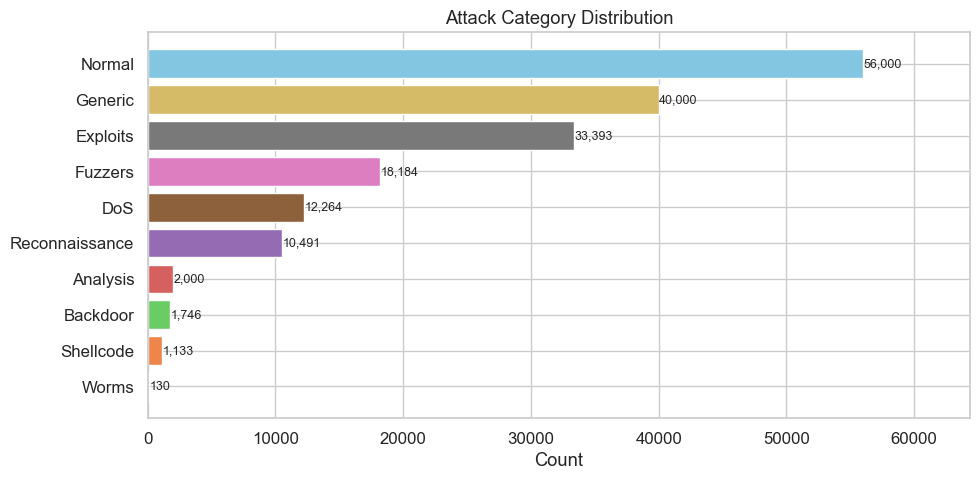

In [12]:
atk_counts = train["attack_cat"].value_counts()
print(atk_counts)

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.barh(atk_counts.index[::-1], atk_counts.values[::-1],
               color=sns.color_palette("muted", len(atk_counts)), edgecolor="white")
for bar, val in zip(bars, atk_counts.values[::-1]):
    ax.text(bar.get_width() + 50, bar.get_y() + bar.get_height() / 2,
            f"{val:,}", va="center", fontsize=9)
ax.set_title("Attack Category Distribution")
ax.set_xlabel("Count")
ax.set_xlim(0, atk_counts.max() * 1.15)
plt.tight_layout()
plt.show()


Unique proto values : 133
proto
tcp          79946
udp          63283
unas         12084
arp           2859
ospf          2595
sctp          1150
any            300
gre            225
sun-nd         201
ipv6           201
mobile         201
swipe          201
pim            201
rsvp           200
sep            193
ib             101
mtp            100
skip           100
merit-inp      100
sps            100
Name: count, dtype: int64


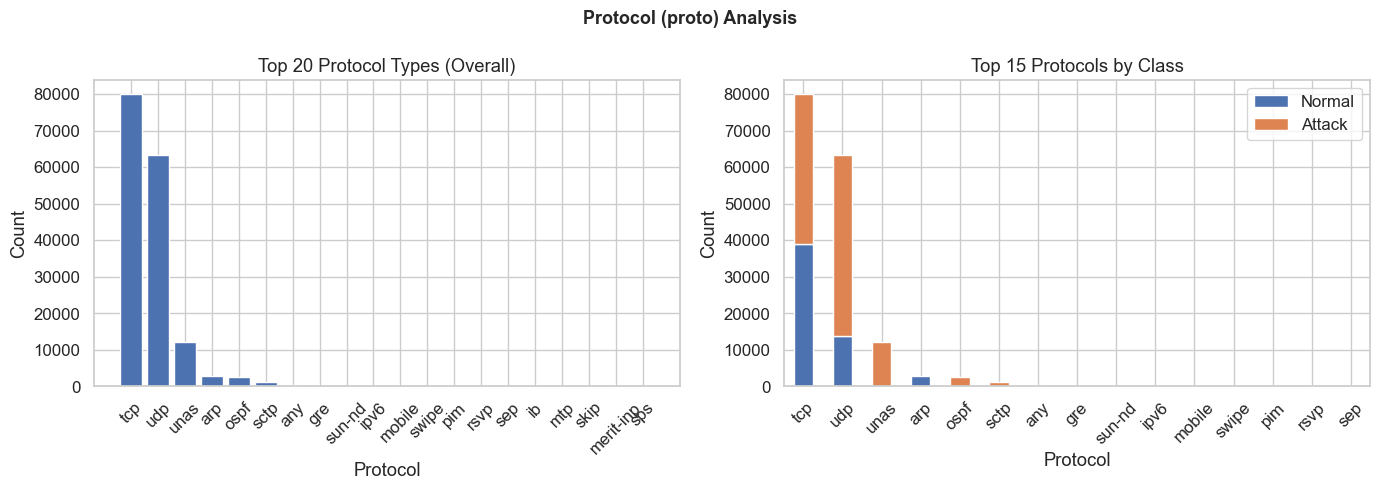

In [13]:

proto_counts = train["proto"].value_counts()
print(f"Unique proto values : {train['proto'].nunique()}")
print(proto_counts.head(20))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))


axes[0].bar(proto_counts.head(20).index, proto_counts.head(20).values,
            color="#4C72B0", edgecolor="white")
axes[0].set_title("Top 20 Protocol Types (Overall)")
axes[0].set_xlabel("Protocol")
axes[0].set_ylabel("Count")
axes[0].tick_params(axis="x", rotation=45)

# Stacked by label
proto_label = train.groupby(["proto", "label"]).size().unstack(fill_value=0)
top_proto = proto_counts.head(15).index
proto_label.loc[top_proto].plot(kind="bar", stacked=True,
                                 color=["#4C72B0", "#DD8452"],
                                 edgecolor="white", ax=axes[1])
axes[1].set_title("Top 15 Protocols by Class")
axes[1].set_xlabel("Protocol")
axes[1].set_ylabel("Count")
axes[1].legend(["Normal", "Attack"])
axes[1].tick_params(axis="x", rotation=45)

plt.suptitle("Protocol (proto) Analysis", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

Unique state values : 9
state
INT    82275
FIN    77825
CON    13152
REQ     1991
RST       83
ECO       12
PAR        1
URN        1
no         1
Name: count, dtype: int64


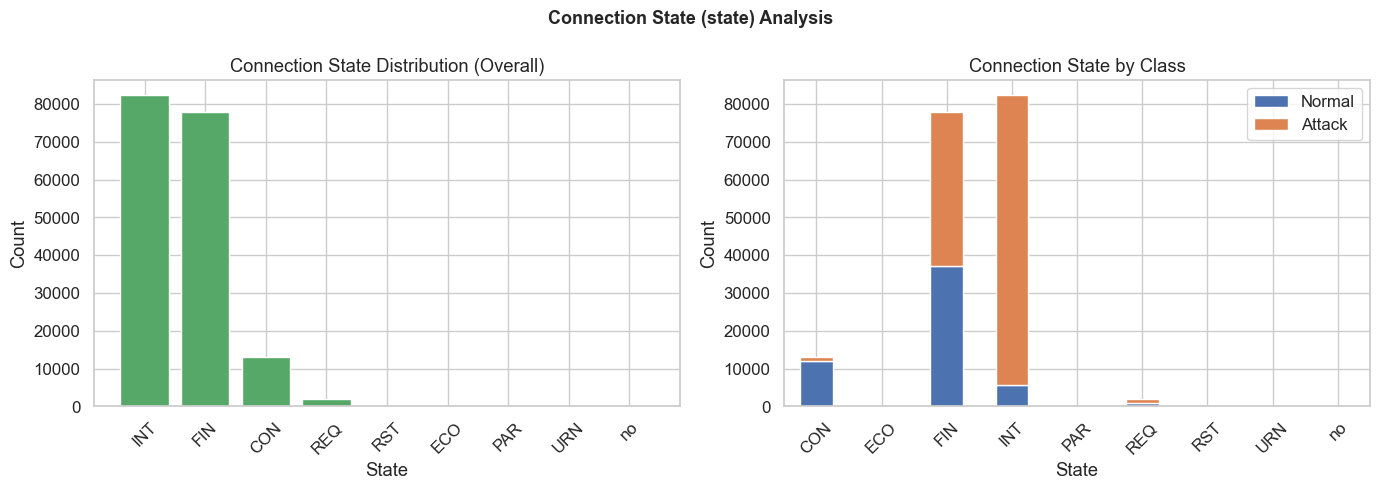

In [14]:

state_counts = train["state"].value_counts()
print(f"Unique state values : {train['state'].nunique()}")
print(state_counts)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].bar(state_counts.index, state_counts.values,
            color="#55A868", edgecolor="white")
axes[0].set_title("Connection State Distribution (Overall)")
axes[0].set_xlabel("State")
axes[0].set_ylabel("Count")
axes[0].tick_params(axis="x", rotation=45)

state_label = train.groupby(["state", "label"]).size().unstack(fill_value=0)
state_label.plot(kind="bar", stacked=True,
                  color=["#4C72B0", "#DD8452"],
                  edgecolor="white", ax=axes[1])
axes[1].set_title("Connection State by Class")
axes[1].set_xlabel("State")
axes[1].set_ylabel("Count")
axes[1].legend(["Normal", "Attack"])
axes[1].tick_params(axis="x", rotation=45)

plt.suptitle("Connection State (state) Analysis", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

Unique service values : 13
service
-           94168
dns         47294
http        18724
smtp         5058
ftp-data     3995
ftp          3428
ssh          1302
pop3         1105
dhcp           94
snmp           80
ssl            56
irc            25
radius         12
Name: count, dtype: int64


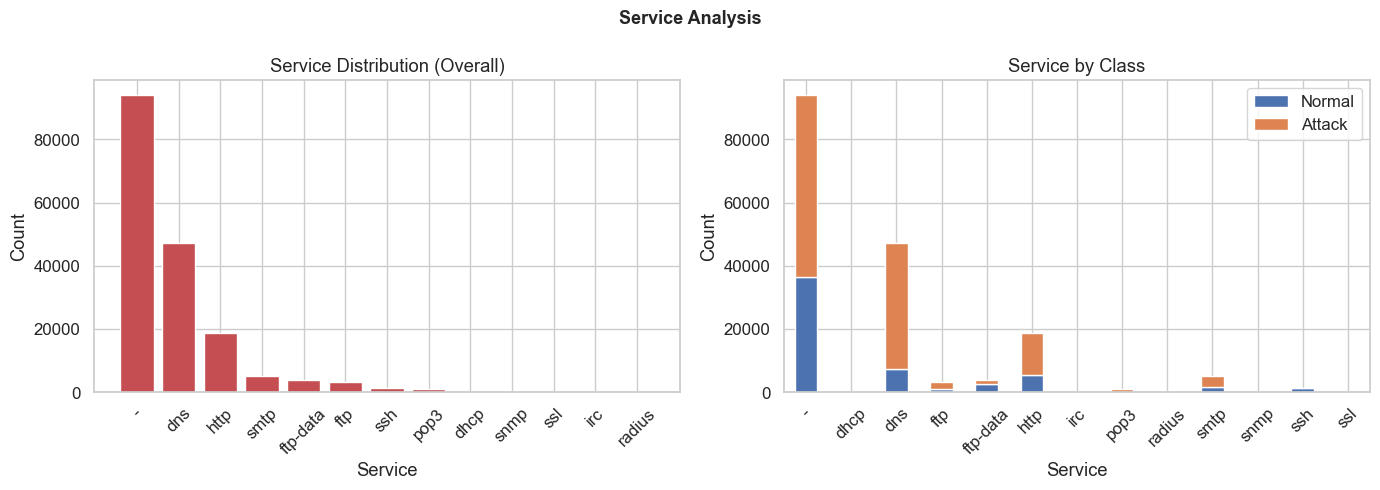

In [15]:

service_counts = train["service"].value_counts()
print(f"Unique service values : {train['service'].nunique()}")
print(service_counts)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].bar(service_counts.index, service_counts.values,
            color="#C44E52", edgecolor="white")
axes[0].set_title("Service Distribution (Overall)")
axes[0].set_xlabel("Service")
axes[0].set_ylabel("Count")
axes[0].tick_params(axis="x", rotation=45)

service_label = train.groupby(["service", "label"]).size().unstack(fill_value=0)
service_label.plot(kind="bar", stacked=True,
                    color=["#4C72B0", "#DD8452"],
                    edgecolor="white", ax=axes[1])
axes[1].set_title("Service by Class")
axes[1].set_xlabel("Service")
axes[1].set_ylabel("Count")
axes[1].legend(["Normal", "Attack"])
axes[1].tick_params(axis="x", rotation=45)

plt.suptitle("Service Analysis", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

In [16]:
num_cols = train.select_dtypes(include=[np.number]).columns.tolist()
num_cols = [c for c in num_cols if c not in ["label"]]
print(f"Numerical features ({len(num_cols)}): {num_cols}")

Numerical features (31): ['dur', 'spkts', 'dpkts', 'sbytes', 'dbytes', 'rate', 'sload', 'dload', 'sloss', 'dloss', 'sinpkt', 'dinpkt', 'sjit', 'djit', 'swin', 'stcpb', 'dtcpb', 'dwin', 'tcprtt', 'synack', 'ackdat', 'smean', 'dmean', 'trans_depth', 'response_body_len', 'ct_src_dport_ltm', 'ct_dst_sport_ltm', 'is_ftp_login', 'ct_ftp_cmd', 'ct_flw_http_mthd', 'is_sm_ips_ports']


In [17]:
skew_kurt = pd.DataFrame({
    "Skewness": train[num_cols].skew(),
    "Kurtosis": train[num_cols].kurt()
}).sort_values("Skewness", ascending=False)

print(skew_kurt.to_string())

                   Skewness  Kurtosis
ackdat              51.7636 3351.9476
synack              45.9808 2327.4299
tcprtt              22.2614  461.6090
is_sm_ips_ports      8.1608   64.6476
ct_ftp_cmd           7.0866   23.8750
is_ftp_login         7.0866   23.8750
ct_flw_http_mthd     0.3517   -2.9951
trans_depth          0.1129   -3.0000
ct_dst_sport_ltm     0.0552   -2.9999
ct_src_dport_ltm     0.0297   -3.0000
dur                  0.0221   -3.0000
swin                 0.0017   -3.0001
dwin                 0.0016   -3.0001
dloss                0.0004   -3.0001
sloss                0.0003   -3.0001
smean                0.0002   -3.0001
dmean                0.0001   -3.0001
dpkts                0.0001   -3.0001
spkts                0.0001   -3.0001
dinpkt               0.0000   -3.0001
djit                 0.0000   -3.0001
sinpkt               0.0000   -3.0001
sjit                 0.0000   -3.0001
response_body_len    0.0000   -3.0001
rate                 0.0000   -3.0001
dbytes      

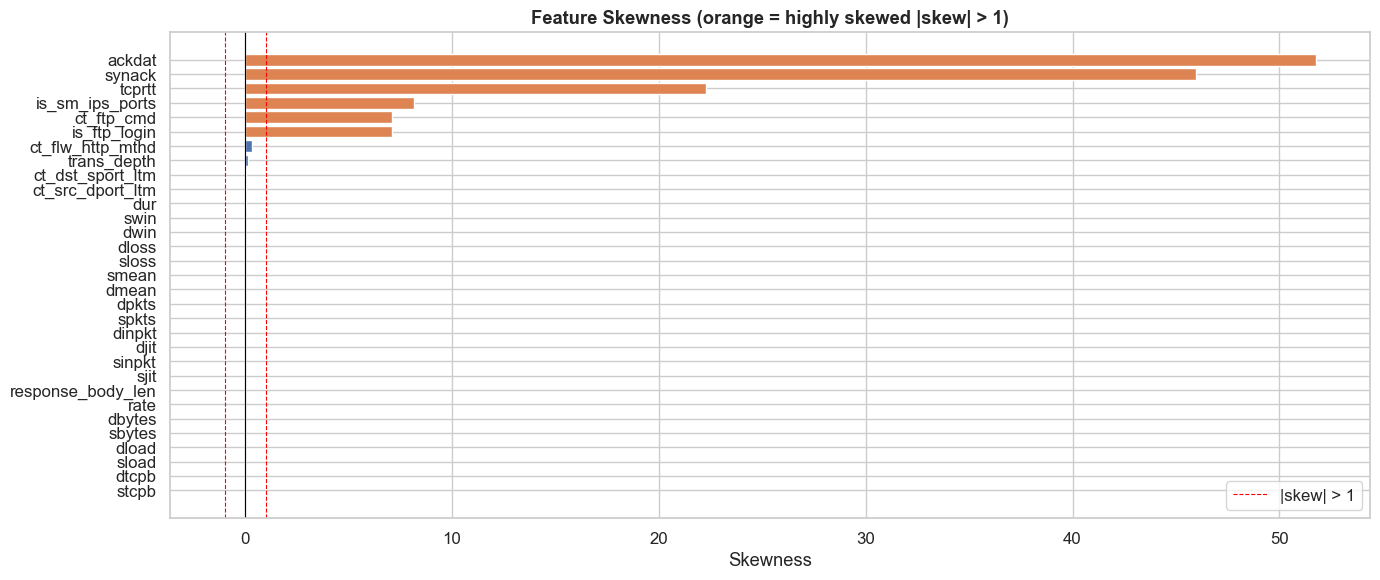

In [18]:
fig, ax = plt.subplots(figsize=(14, 6))
colors = ["#DD8452" if abs(v) > 1 else "#4C72B0" for v in skew_kurt["Skewness"]]
ax.barh(skew_kurt.index[::-1], skew_kurt["Skewness"].values[::-1],
        color=colors[::-1], edgecolor="white")
ax.axvline(0, color="black", linewidth=0.8)
ax.axvline(1, color="red", linewidth=0.8, linestyle="--", label="|skew| > 1")
ax.axvline(-1, color="red", linewidth=0.8, linestyle="--")
ax.set_title("Feature Skewness (orange = highly skewed |skew| > 1)", fontweight="bold")
ax.set_xlabel("Skewness")
ax.legend()
plt.tight_layout()
plt.show()

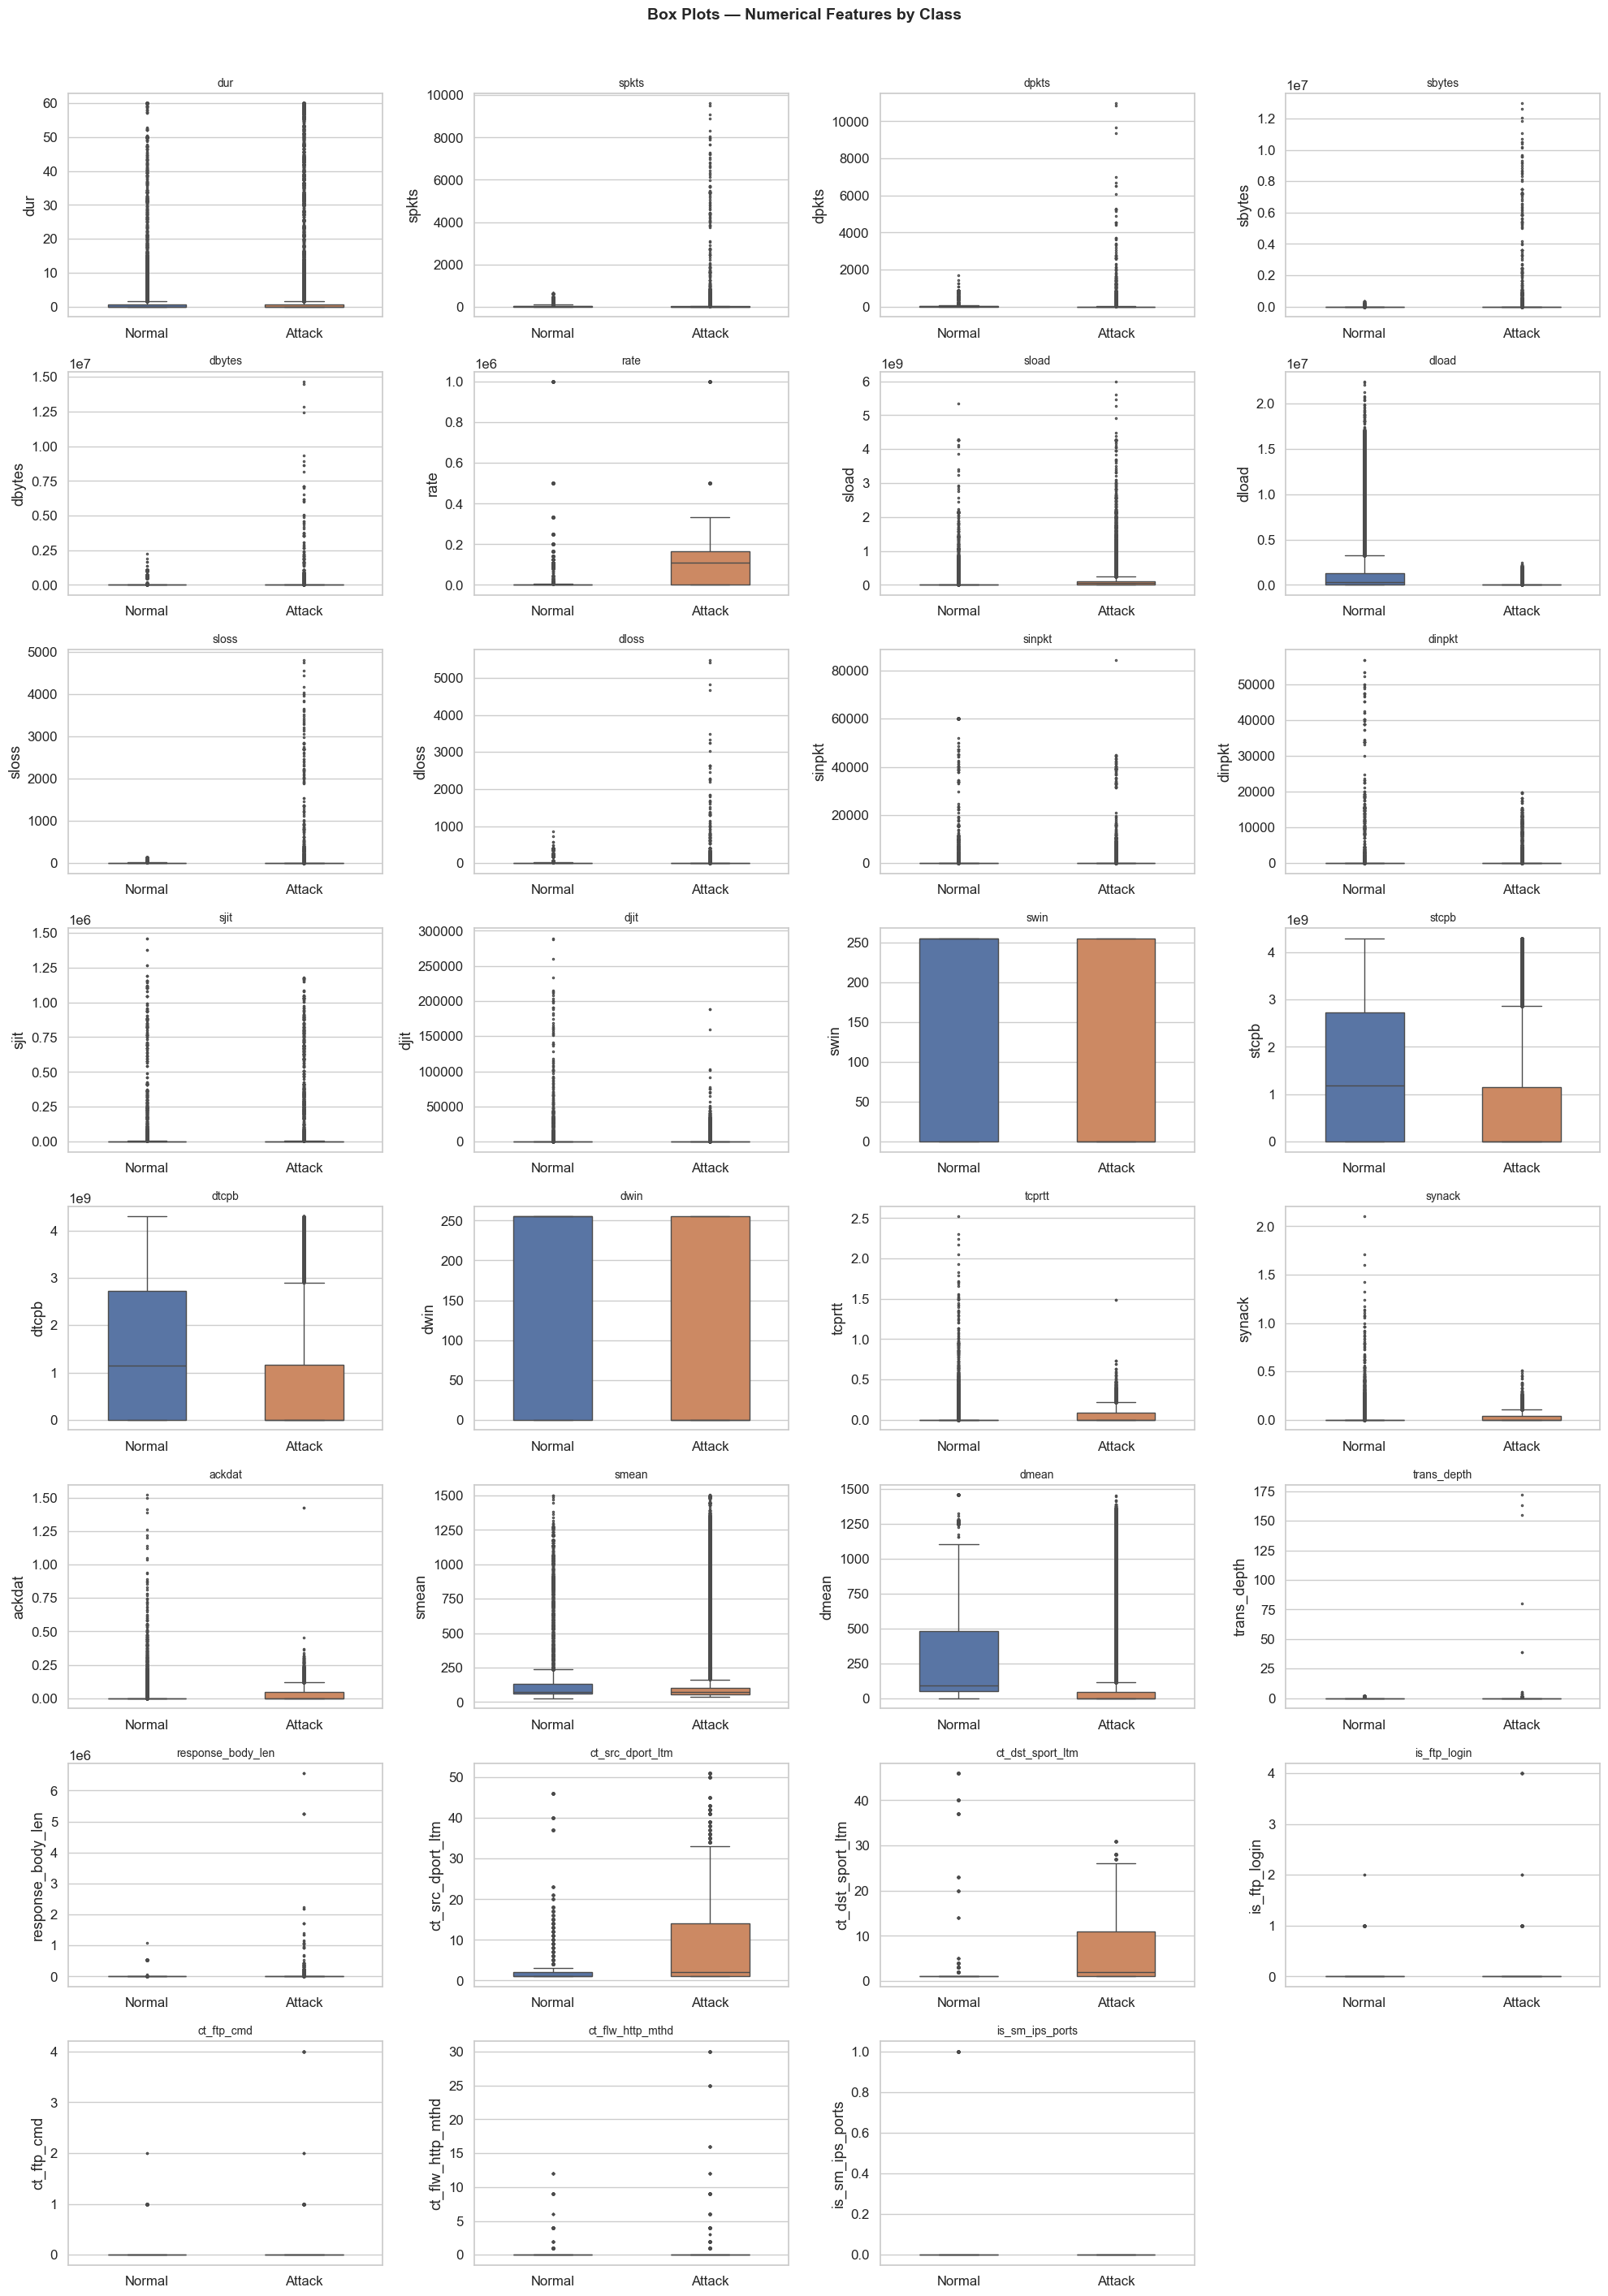

In [19]:
n_cols_plot = 4
n_rows_plot = int(np.ceil(len(num_cols) / n_cols_plot))

fig, axes = plt.subplots(n_rows_plot, n_cols_plot,
                         figsize=(20, n_rows_plot * 3.5))
axes = axes.flatten()

for i, col in enumerate(num_cols):
    sns.boxplot(data=train, x="label", y=col,
                palette=["#4C72B0", "#DD8452"],
                width=0.5, fliersize=1.5, ax=axes[i])
    axes[i].set_title(col, fontsize=10)
    axes[i].set_xticklabels(["Normal", "Attack"])
    axes[i].set_xlabel("")

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle("Box Plots — Numerical Features by Class", fontsize=14, fontweight="bold", y=1.01)
plt.tight_layout()
plt.show()

In [20]:
outlier_summary = []
for col in num_cols:
    q1  = train[col].quantile(0.25)
    q3  = train[col].quantile(0.75)
    iqr = q3 - q1
    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr
    n_out = ((train[col] < lower) | (train[col] > upper)).sum()
    outlier_summary.append({
        "Feature":         col,
        "Q1":              round(q1, 4),
        "Q3":              round(q3, 4),
        "IQR":             round(iqr, 4),
        "Lower Bound":     round(lower, 4),
        "Upper Bound":     round(upper, 4),
        "Outlier Count":   n_out,
        "Outlier %":       round(n_out / len(train) * 100, 2)
    })

outlier_df = pd.DataFrame(outlier_summary).sort_values("Outlier %", ascending=False)
print(outlier_df.to_string(index=False))


          Feature         Q1              Q3             IQR      Lower Bound     Upper Bound  Outlier Count  Outlier %
            dload     0.0000      27844.8710      27844.8710      -41767.3065      69612.1775          38143    21.7500
 ct_dst_sport_ltm     1.0000          3.0000          2.0000          -2.0000          6.0000          37337    21.2900
 ct_src_dport_ltm     1.0000          5.0000          4.0000          -5.0000         11.0000          33423    19.0600
           synack     0.0000          0.0233          0.0233          -0.0349          0.0582          31462    17.9400
            dloss     0.0000          2.0000          2.0000          -3.0000          5.0000          28388    16.1900
           dbytes     0.0000       1102.0000       1102.0000       -1653.0000       2755.0000          28131    16.0400
            spkts     2.0000         12.0000         10.0000         -13.0000         27.0000          24675    14.0700
            dmean     0.0000         89.

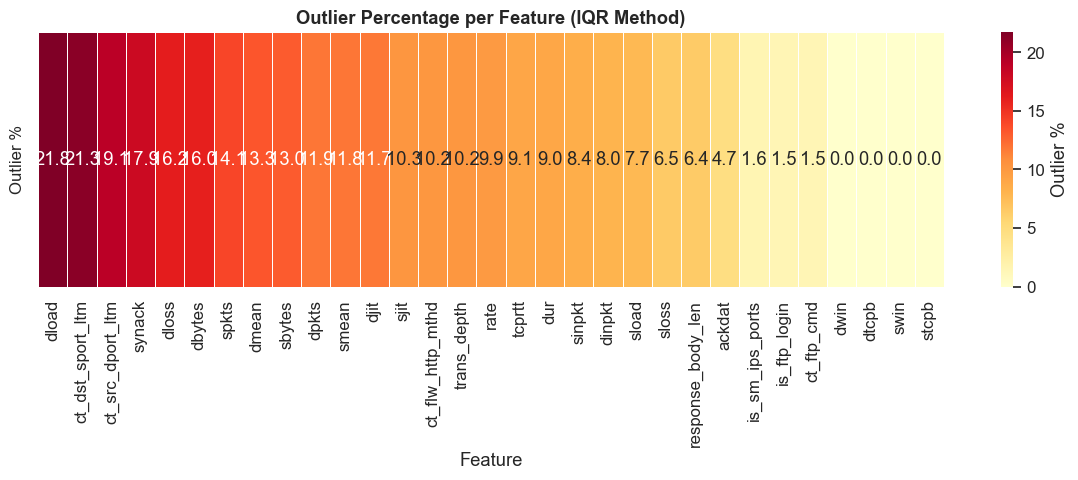

In [21]:
fig, ax = plt.subplots(figsize=(12, 5))
hm_data = outlier_df.set_index("Feature")[["Outlier %"]].T
sns.heatmap(hm_data, annot=True, fmt=".1f", cmap="YlOrRd",
            linewidths=0.5, ax=ax, cbar_kws={"label": "Outlier %"})
ax.set_title("Outlier Percentage per Feature (IQR Method)", fontweight="bold")
plt.tight_layout()
plt.show()

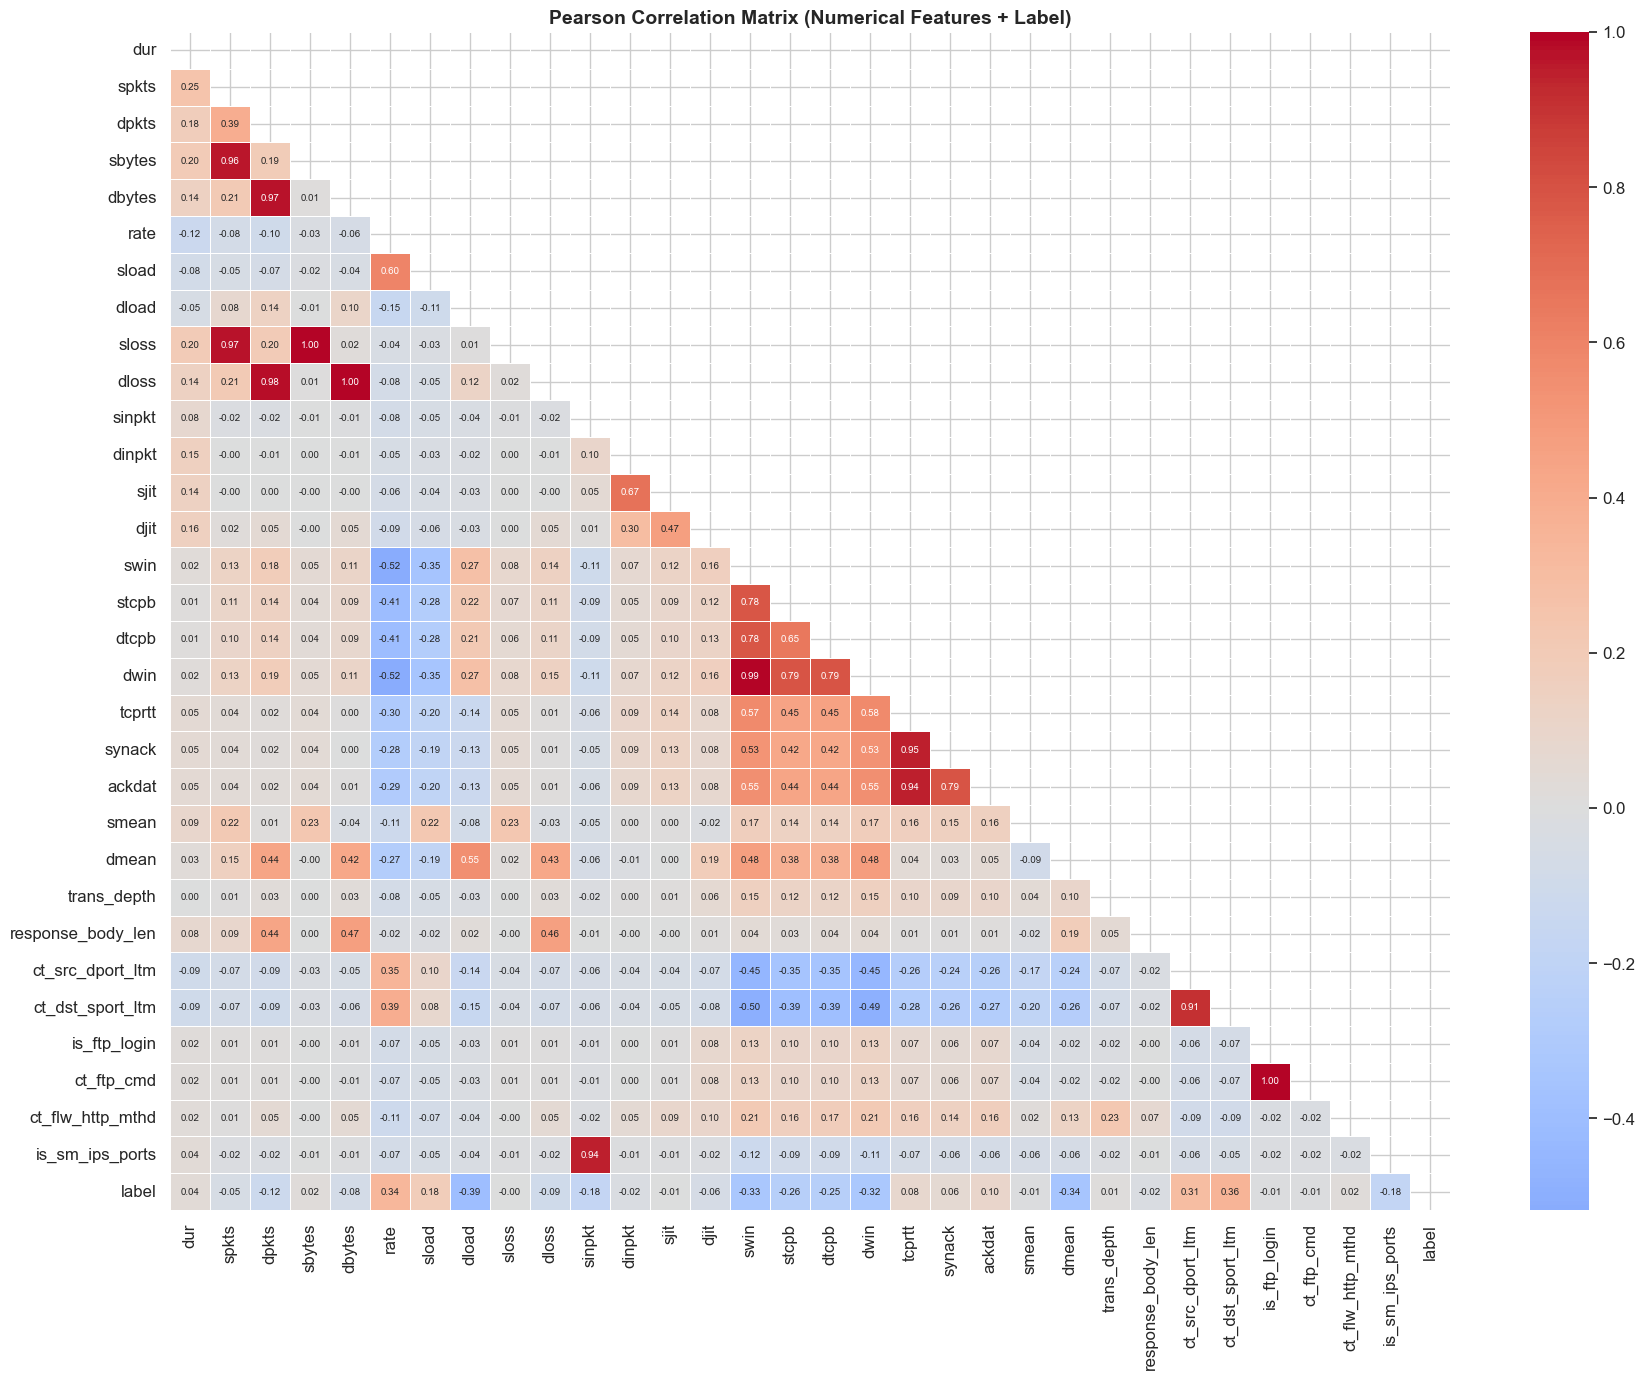

In [22]:
corr = train[num_cols + ["label"]].corr()

fig, ax = plt.subplots(figsize=(18, 14))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt=".2f",
            cmap="coolwarm", center=0, linewidths=0.4,
            annot_kws={"size": 7}, ax=ax)
ax.set_title("Pearson Correlation Matrix (Numerical Features + Label)", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

Top correlations with label:
dload               0.3937
ct_dst_sport_ltm    0.3572
dmean               0.3418
rate                0.3380
swin                0.3336
dwin                0.3196
ct_src_dport_ltm    0.3056
stcpb               0.2550
dtcpb               0.2503
is_sm_ips_ports     0.1847
sload               0.1829
sinpkt              0.1761
dpkts               0.1186
ackdat              0.0974
dloss               0.0947
tcprtt              0.0816
dbytes              0.0769
djit                0.0609
synack              0.0583
spkts               0.0522
dur                 0.0362
dinpkt              0.0229
response_body_len   0.0214
sbytes              0.0186
ct_flw_http_mthd    0.0158
is_ftp_login        0.0111
ct_ftp_cmd          0.0111
trans_depth         0.0108
smean               0.0108
sjit                0.0071
sloss               0.0006


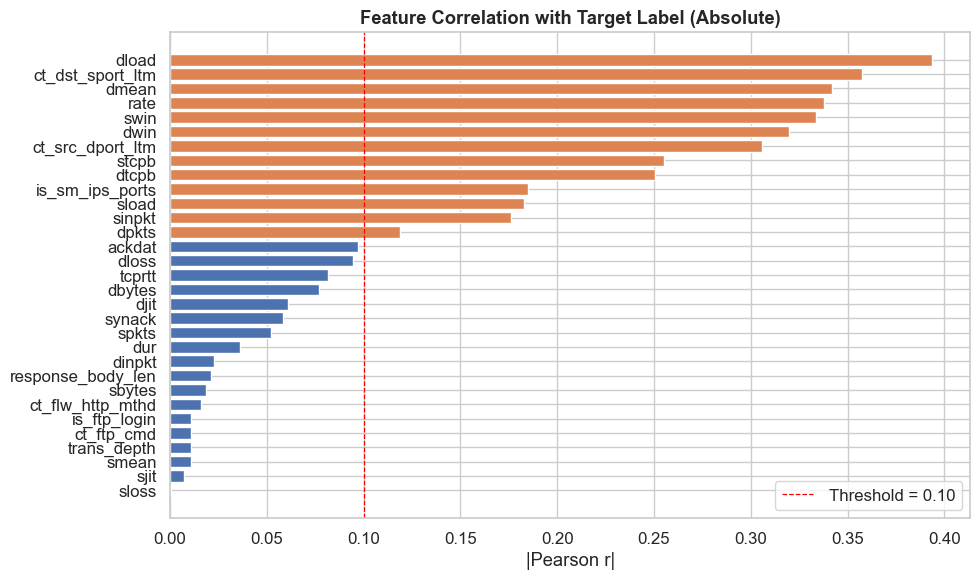

In [23]:
label_corr = corr["label"].drop("label").abs().sort_values(ascending=False)
print("Top correlations with label:")
print(label_corr.to_string())

fig, ax = plt.subplots(figsize=(10, 6))
colors = ["#DD8452" if v >= 0.1 else "#4C72B0" for v in label_corr.values]
ax.barh(label_corr.index[::-1], label_corr.values[::-1],
        color=colors[::-1], edgecolor="white")
ax.axvline(0.1, color="red", linewidth=0.9, linestyle="--", label="Threshold = 0.10")
ax.set_title("Feature Correlation with Target Label (Absolute)", fontweight="bold")
ax.set_xlabel("|Pearson r|")
ax.legend()
plt.tight_layout()
plt.show()


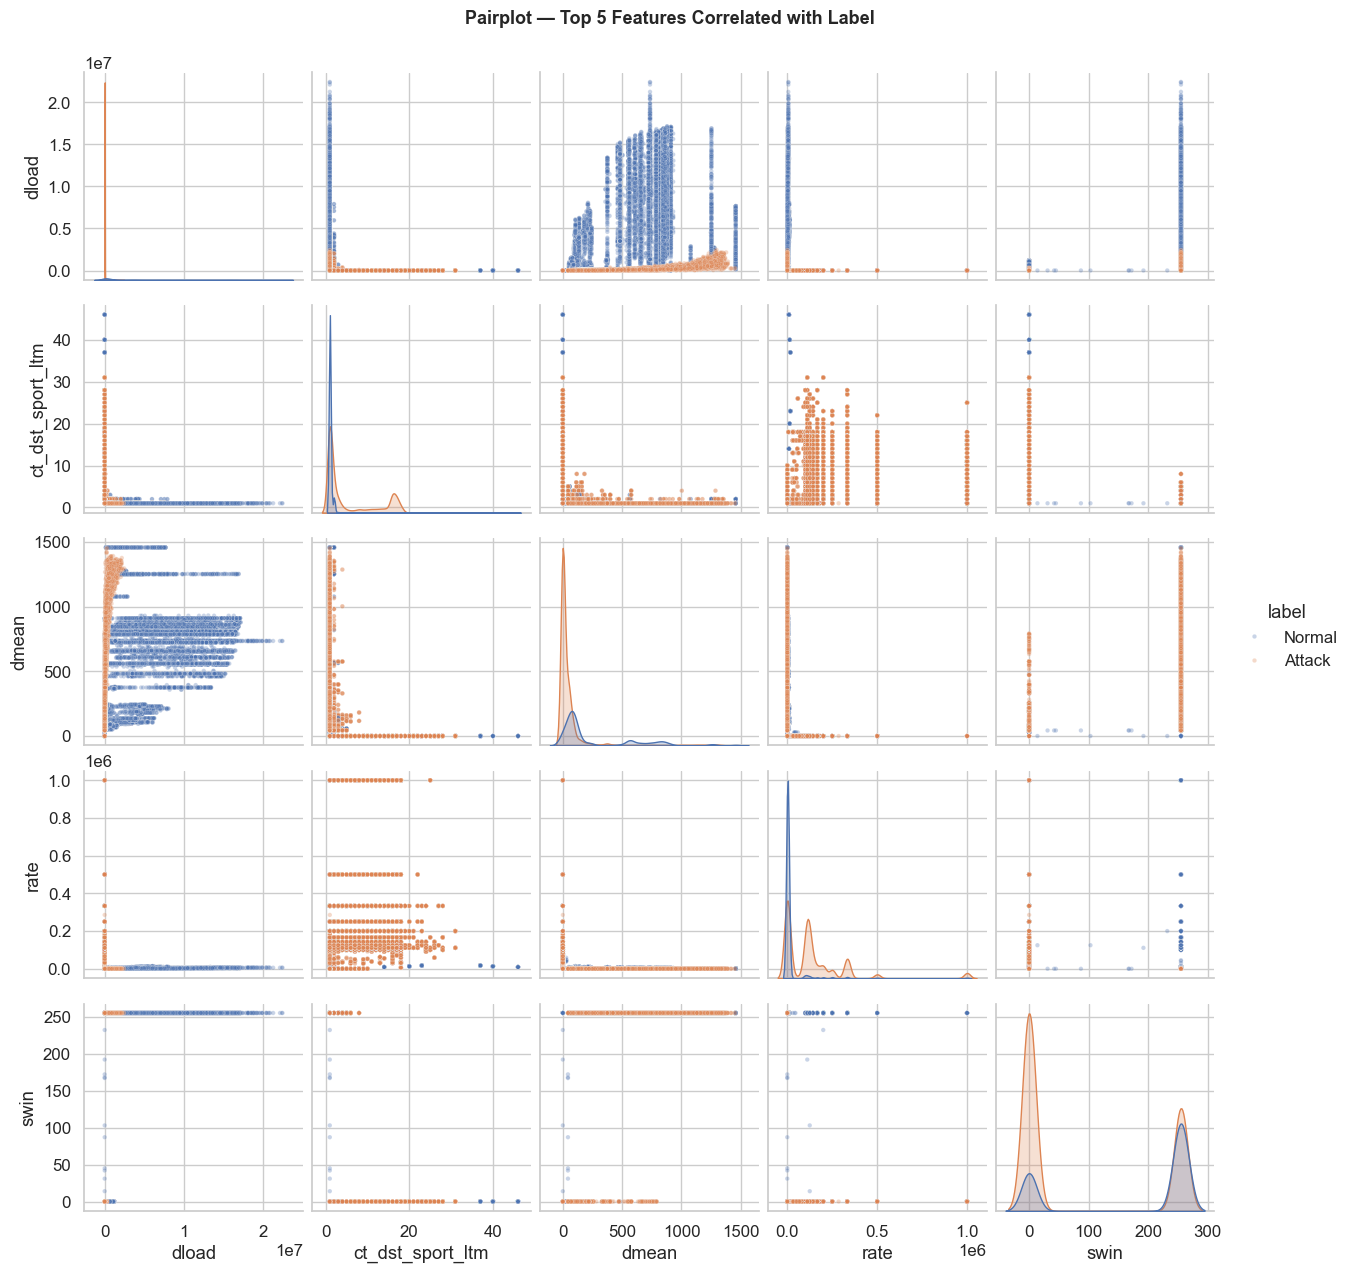

In [24]:
top5 = label_corr.head(5).index.tolist()
pair_df = train[top5 + ["label"]].copy()
pair_df["label"] = pair_df["label"].map({0: "Normal", 1: "Attack"})

g = sns.pairplot(pair_df, hue="label",
                 palette={"Normal": "#4C72B0", "Attack": "#DD8452"},
                 diag_kind="kde", plot_kws={"alpha": 0.3, "s": 10})
g.fig.suptitle("Pairplot — Top 5 Features Correlated with Label", y=1.02,
               fontsize=13, fontweight="bold")
plt.show()



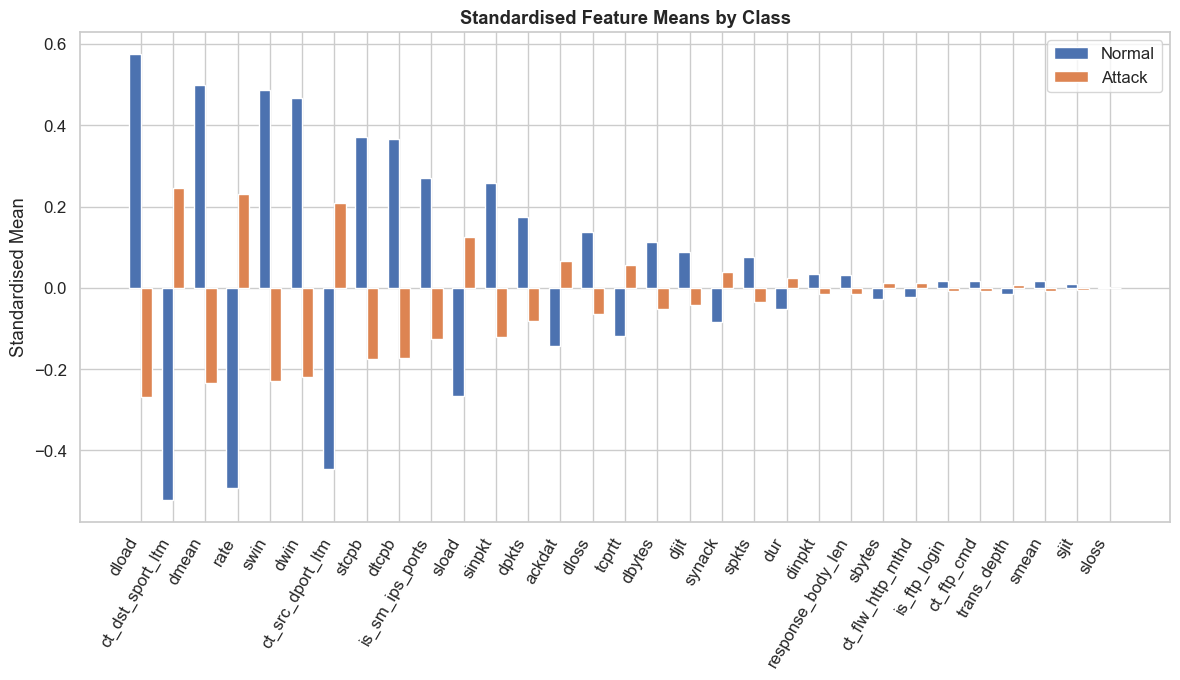


Feature difference (Attack - Normal, standardised):
                   Normal  Attack  Difference
dload              0.5748 -0.2697      0.8445
ct_dst_sport_ltm  -0.5215  0.2447      0.7662
dmean              0.4990 -0.2341      0.7331
rate              -0.4934  0.2315      0.7249
swin               0.4870 -0.2285      0.7156
dwin               0.4666 -0.2189      0.6855
ct_src_dport_ltm  -0.4461  0.2093      0.6554
stcpb              0.3723 -0.1747      0.5469
dtcpb              0.3655 -0.1715      0.5369
is_sm_ips_ports    0.2696 -0.1265      0.3961
sload             -0.2670  0.1253      0.3922
sinpkt             0.2571 -0.1206      0.3777
dpkts              0.1731 -0.0812      0.2544
ackdat            -0.1421  0.0667      0.2088
dloss              0.1382 -0.0649      0.2031
tcprtt            -0.1191  0.0559      0.1750
dbytes             0.1122 -0.0527      0.1649
djit               0.0889 -0.0417      0.1306
synack            -0.0851  0.0399      0.1250
spkts              0.0762 -

In [25]:
from sklearn.preprocessing import StandardScaler

scaler  = StandardScaler()
scaled  = pd.DataFrame(scaler.fit_transform(train[num_cols]),
                        columns=num_cols)
scaled["label"] = train["label"].values

mean_by_class = scaled.groupby("label")[num_cols].mean().T
mean_by_class.columns = ["Normal", "Attack"]
mean_by_class["Difference"] = (mean_by_class["Attack"] - mean_by_class["Normal"]).abs()
mean_by_class = mean_by_class.sort_values("Difference", ascending=False)

fig, ax = plt.subplots(figsize=(12, 7))
x = np.arange(len(mean_by_class))
width = 0.35
ax.bar(x - width / 2, mean_by_class["Normal"], width,
       label="Normal", color="#4C72B0", edgecolor="white")
ax.bar(x + width / 2, mean_by_class["Attack"], width,
       label="Attack", color="#DD8452", edgecolor="white")
ax.set_xticks(x)
ax.set_xticklabels(mean_by_class.index, rotation=60, ha="right")
ax.set_title("Standardised Feature Means by Class", fontweight="bold")
ax.set_ylabel("Standardised Mean")
ax.legend()
plt.tight_layout()
plt.show()

print("\nFeature difference (Attack - Normal, standardised):")
print(mean_by_class[["Normal", "Attack", "Difference"]].to_string())

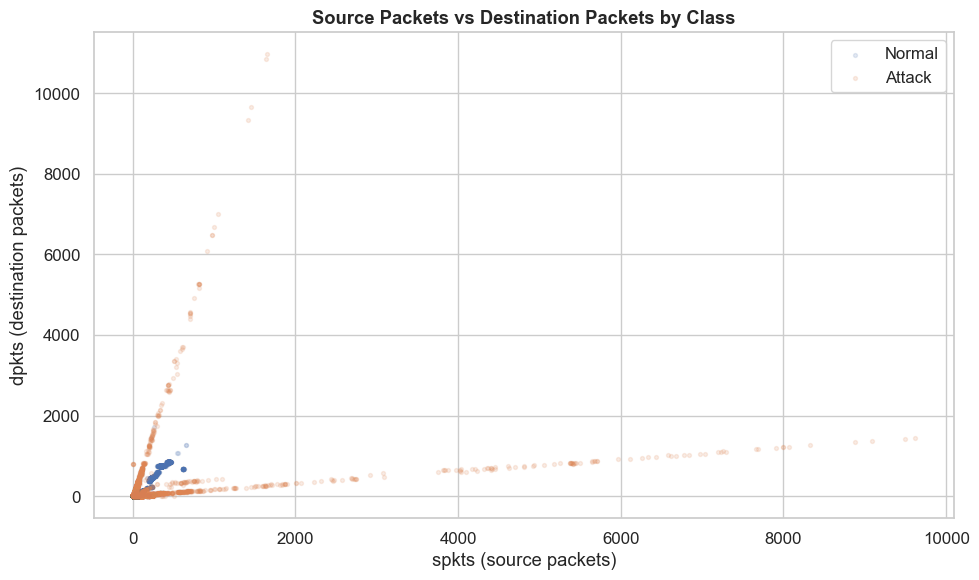

In [26]:

fig, ax = plt.subplots(figsize=(10, 6))
for label, color, name in [(0, "#4C72B0", "Normal"), (1, "#DD8452", "Attack")]:
    subset = train[train["label"] == label]
    ax.scatter(subset["spkts"], subset["dpkts"],
               alpha=0.15, s=8, c=color, label=name)
ax.set_xlabel("spkts (source packets)")
ax.set_ylabel("dpkts (destination packets)")
ax.set_title("Source Packets vs Destination Packets by Class", fontweight="bold")
ax.legend()
plt.tight_layout()
plt.show()

In [28]:
binary_cols = ["is_ftp_login", "is_sm_ips_ports"]
lowcard_cols = ["trans_depth", "ct_ftp_cmd", "ct_flw_http_mthd"]

for col in binary_cols + lowcard_cols:
    print(f"\n--- {col} ---")
    print(train.groupby([col, "label"]).size().unstack(fill_value=0).rename(columns={0: "Normal", 1: "Attack"}))



--- is_ftp_login ---
label         Normal  Attack
is_ftp_login                
0              55051  117723
1                947    1598
2                  2       4
4                  0      16

--- is_sm_ips_ports ---
label            Normal  Attack
is_sm_ips_ports                
0                 53238  119341
1                  2762       0

--- trans_depth ---
label        Normal  Attack
trans_depth                
0             50820  106681
1              5111   12636
2                69      11
3                 0       2
4                 0       3
5                 0       2
39                0       2
80                0       1
155               0       1
163               0       1
172               0       1

--- ct_ftp_cmd ---
label       Normal  Attack
ct_ftp_cmd                
0            55051  117723
1              947    1598
2                2       4
4                0      16

--- ct_flw_http_mthd ---
label             Normal  Attack
ct_flw_http_mthd         

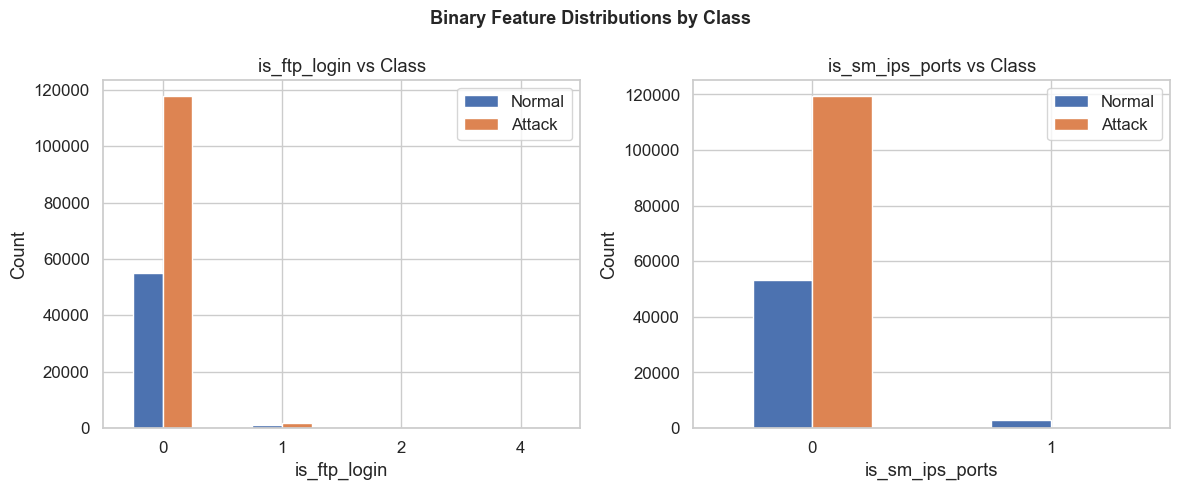

In [29]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for ax, col in zip(axes, binary_cols):
    data = train.groupby([col, "label"]).size().unstack(fill_value=0)
    data.columns = ["Normal", "Attack"]
    data.plot(kind="bar", color=["#4C72B0", "#DD8452"],
              edgecolor="white", ax=ax)
    ax.set_title(f"{col} vs Class")
    ax.set_xlabel(col)
    ax.set_ylabel("Count")
    ax.tick_params(axis="x", rotation=0)
    ax.legend()

plt.suptitle("Binary Feature Distributions by Class", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()